In [1]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from einops import einsum
from jaxtyping import Float
from pydantic import ConfigDict
from pydantic.dataclasses import dataclass
from tqdm.auto import tqdm

from src.config.base import ConfigMethodsMixin
from src.data.base import DataConfig
from src.data.dataloading import DataLoaderConfig
from src.data.unity_gaussian_mixture.config import UnityGaussianMixtureDatasetConfig
from src.method.latent_generation.config import (
    FlowMatchingLatentNoiseWeightConfig,
    LatentGenerationLossConfig,
    LatentGenerationMethodConfig,
    LatentGenerationModelConfig,
)
from src.model.mlp import StackedResidualMLPConfig
from src.model.time_conditioning import TimeConditioningConfig
from src.utils import set_seed

SEED = 42

set_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)
print("seed:", SEED)

device: cuda
seed: 42


In [ ]:
@dataclass(
    kw_only=True,
    config=ConfigDict(
        arbitrary_types_allowed=True,
        extra="forbid",
    ),
)
class ExperimentConfig(ConfigMethodsMixin):
    method_config: LatentGenerationMethodConfig
    lr: float
    train_epochs: int
    log_every_epochs: int
    grad_clip: float


dataset_config = UnityGaussianMixtureDatasetConfig(
    num_modes=5,
    ambient_dim=32,
    mode_std=0.1,
    ring_radius_in_zscore=1.5,
    scale=1.0,
    offset_norm=0.0,
    embed_seed=7,
    train_size=2048 * 128,
    val_size=2048 * 16,
)

dataloader_config = DataLoaderConfig(
    batch_size=2048,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
    drop_last=True,
)
data_config = DataConfig(
    seed=SEED,
    dataset_config=dataset_config,
    trainloader_config=dataloader_config,
    valloader_config=dataloader_config,
)

encoder_config = StackedResidualMLPConfig.initialize(
    layer_dims=[dataset_config.ambient_dim, 256, 256, 256, dataset_config.ambient_dim],
    time_conditioning_config=TimeConditioningConfig(
        min_t_lambda=0.01,
        max_t_lambda=1.0,
        sinusoidal_dim=64,
        hidden_dim=256,
        output_dim=256,
    ),
)

decoder_config = StackedResidualMLPConfig.initialize(
    layer_dims=[dataset_config.ambient_dim, 256, 256, dataset_config.ambient_dim],
)

config = ExperimentConfig(
    method_config=LatentGenerationMethodConfig(
        model=LatentGenerationModelConfig(
            encoder_config=encoder_config,
            decoder_config=decoder_config,
            latent_shape=(dataset_config.ambient_dim,),
        ),
        loss=LatentGenerationLossConfig(
            t_min=0.05,
            noise_weight=FlowMatchingLatentNoiseWeightConfig(),
            reconstruction_weight=1.0,
            prior_matching_weight=1.0,
            cycle_data_weight=1.0,
            cycle_prior_weight=1.0,
            denoising_weight=1.0,
            score_weight=1.0,
            rev_score_weight=1.0,
        ),
    ),
    lr=3e-4,
    train_epochs=24,
    log_every_epochs=1,
    grad_clip=1.0,
)
config.visualize()

In [ ]:
def project_to_plane(
    points_hd: Float[torch.Tensor, "batch ambient_dim"],
    basis: Float[torch.Tensor, "ambient_dim plane_dim"],
    dataset_config: UnityGaussianMixtureDatasetConfig,
) -> Float[torch.Tensor, "batch plane_dim"]:
    displacement = dataset_config.get_displacement().to(
        device=points_hd.device, dtype=points_hd.dtype
    )
    centered = points_hd - displacement
    return (
        einsum(
            centered,
            basis,
            "batch ambient_dim, ambient_dim plane_dim -> batch plane_dim",
        )
        / dataset_config.scale
    )


def orthogonal_residual(
    points_hd: Float[torch.Tensor, "batch ambient_dim"],
    basis: Float[torch.Tensor, "ambient_dim plane_dim"],
    dataset_config: UnityGaussianMixtureDatasetConfig,
) -> Float[torch.Tensor, "batch ambient_dim"]:
    displacement = dataset_config.get_displacement().to(
        device=points_hd.device, dtype=points_hd.dtype
    )
    projected = project_to_plane(points_hd, basis, dataset_config)
    lifted = einsum(
        projected,
        basis,
        "batch plane_dim, ambient_dim plane_dim -> batch ambient_dim",
    )
    lifted = dataset_config.scale * lifted + displacement
    return points_hd - lifted


basis = data_config.dataset_config.get_basis().to(DEVICE)
train_loader = data_config.get_trainloader()
val_loader = data_config.get_valloader()
preview_batch = next(iter(val_loader)).to(DEVICE)
preview_batch.x_hd.shape, preview_batch.x_2d.shape

(torch.Size([2048, 32]), torch.Size([2048, 2]))

In [ ]:
def collect_metrics(
    config: ExperimentConfig,
    data_config: DataConfig,
    val_loader: torch.utils.data.DataLoader,
    basis: Float[torch.Tensor, "ambient_dim plane_dim"],
    model: nn.Module,
    device: torch.device,
) -> dict[str, float]:
    model.eval()
    with torch.no_grad():
        batch = next(iter(val_loader)).to(device)
        eval_size = int(batch.x_hd.shape[0])
        x_true = batch.data()
        y_true = model.encode(x=x_true)
        x_recon = model.decode(y=y_true)
        z = torch.randn(
            eval_size,
            *config.method_config.model.latent_shape,
            device=device,
        )
        x_gen = model.decode(y=z)
        recon_mse = F.mse_loss(x_recon, x_true).item()
        recon_plane_mse = F.mse_loss(
            project_to_plane(x_recon, basis, data_config.dataset_config), batch.x_2d
        ).item()
        recon_offplane = (
            orthogonal_residual(x_recon, basis, data_config.dataset_config)
            .norm(dim=-1)
            .mean()
            .item()
        )
        gen_offplane = (
            orthogonal_residual(x_gen, basis, data_config.dataset_config)
            .norm(dim=-1)
            .mean()
            .item()
        )
        gen_radius = (
            project_to_plane(x_gen, basis, data_config.dataset_config)
            .norm(dim=-1)
            .mean()
            .item()
        )
    model.train()
    return {
        "recon_mse": recon_mse,
        "recon_plane_mse": recon_plane_mse,
        "recon_offplane": recon_offplane,
        "gen_offplane": gen_offplane,
        "gen_radius": gen_radius,
    }


def train_experiment(
    config: ExperimentConfig,
    data_config: DataConfig,
    train_loader: torch.utils.data.DataLoader,
    val_loader: torch.utils.data.DataLoader,
    basis: Float[torch.Tensor, "ambient_dim plane_dim"],
    model: nn.Module,
    device: torch.device,
) -> dict[str, list[float]]:
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr, weight_decay=0.01)
    state = config.method_config.initialize_state()
    steps_per_epoch = len(train_loader)

    history: dict[str, list[float]] = {
        "step": [],
        "total_loss": [],
        "prior_loss": [],
        "cycle_plus_loss": [],
        "cycle_minus_loss": [],
        "dpi_loss": [],
        "denoise_loss": [],
        "score_loss": [],
        "recon_mse": [],
        "recon_plane_mse": [],
        "recon_offplane": [],
        "gen_offplane": [],
        "gen_radius": [],
    }

    progress_bar = tqdm(
        range(1, config.train_epochs + 1),
        desc="training",
        unit="epoch",
    )
    for epoch in progress_bar:
        epoch_total_loss = 0.0
        epoch_prior_loss = 0.0
        epoch_cycle_plus_loss = 0.0
        epoch_cycle_minus_loss = 0.0
        epoch_dpi_loss = 0.0
        epoch_denoise_loss = 0.0
        epoch_score_loss = 0.0

        for batch_index, batch in enumerate(train_loader, start=1):
            batch = batch.to(device)

            optimizer.zero_grad(set_to_none=True)
            output = state.compute_losses(model=model, batch=batch)
            weighted_loss_terms = dict(output.weighted_loss_terms)
            unweighted_loss_terms = dict(output.unweighted_loss_terms)
            total_loss = sum(weighted_loss_terms.values())

            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), config.grad_clip)
            optimizer.step()

            epoch_total_loss += float(total_loss.item())
            epoch_prior_loss += float(unweighted_loss_terms["prior_matching"].item())
            epoch_cycle_plus_loss += float(unweighted_loss_terms["cycle_data"].item())
            epoch_cycle_minus_loss += float(unweighted_loss_terms["cycle_prior"].item())
            epoch_dpi_loss += float(unweighted_loss_terms["reconstruction"].item())
            epoch_denoise_loss += float(unweighted_loss_terms["denoising"].item())
            epoch_score_loss += float(unweighted_loss_terms["score"].item())

        if (
            epoch == 1
            or epoch % config.log_every_epochs == 0
            or epoch == config.train_epochs
        ):
            metrics = collect_metrics(
                config=config,
                data_config=data_config,
                val_loader=val_loader,
                basis=basis,
                model=model,
                device=device,
            )
            history["step"].append(epoch * steps_per_epoch)
            history["total_loss"].append(epoch_total_loss / steps_per_epoch)
            history["prior_loss"].append(epoch_prior_loss / steps_per_epoch)
            history["cycle_plus_loss"].append(epoch_cycle_plus_loss / steps_per_epoch)
            history["cycle_minus_loss"].append(epoch_cycle_minus_loss / steps_per_epoch)
            history["dpi_loss"].append(epoch_dpi_loss / steps_per_epoch)
            history["denoise_loss"].append(epoch_denoise_loss / steps_per_epoch)
            history["score_loss"].append(epoch_score_loss / steps_per_epoch)
            history["recon_mse"].append(metrics["recon_mse"])
            history["recon_plane_mse"].append(metrics["recon_plane_mse"])
            history["recon_offplane"].append(metrics["recon_offplane"])
            history["gen_offplane"].append(metrics["gen_offplane"])
            history["gen_radius"].append(metrics["gen_radius"])
            progress_bar.set_postfix(
                total=f"{history['total_loss'][-1]:.4f}",
                prior=f"{history['prior_loss'][-1]:.4f}",
                cycle_plus=f"{history['cycle_plus_loss'][-1]:.4f}",
                cycle_minus=f"{history['cycle_minus_loss'][-1]:.4f}",
                dpi=f"{history['dpi_loss'][-1]:.4f}",
                denoise=f"{history['denoise_loss'][-1]:.4f}",
                score=f"{history['score_loss'][-1]:.4f}",
            )

    return history


def make_snapshot(
    config: ExperimentConfig,
    val_loader: torch.utils.data.DataLoader,
    model: nn.Module,
    device: torch.device,
) -> dict[str, torch.Tensor]:
    model.eval()
    with torch.no_grad():
        batch = next(iter(val_loader)).to(device)
        sample_size = int(batch.x_hd.shape[0])
        x_true_hd = batch.x_hd
        y_true = model.encode(x=x_true_hd)
        x_recon_hd = model.decode(y=y_true)
        z = torch.randn(
            sample_size,
            *config.method_config.model.latent_shape,
            device=device,
        )
        x_gen_hd = model.decode(y=z)
    model.train()
    return {
        "x_true_hd": x_true_hd.detach().cpu(),
        "x_recon_hd": x_recon_hd.detach().cpu(),
        "x_gen_hd": x_gen_hd.detach().cpu(),
    }


def plot_training_curves(history: dict[str, list[float]]) -> None:
    steps = history["step"]
    fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)

    axes[0, 0].plot(steps, history["cycle_plus_loss"], label="+")
    axes[0, 0].plot(steps, history["cycle_minus_loss"], label="-")
    axes[0, 0].set_title("Cycle Loss")
    axes[0, 0].set_xlabel("steps")
    axes[0, 0].legend()

    axes[0, 1].plot(steps, history["dpi_loss"])
    axes[0, 1].set_title("DPI")
    axes[0, 1].set_xlabel("steps")

    axes[0, 2].plot(steps, history["prior_loss"])
    axes[0, 2].set_title("Prior")
    axes[0, 2].set_xlabel("steps")

    axes[1, 0].plot(steps, history["denoise_loss"])
    axes[1, 0].set_title("Denoise")
    axes[1, 0].set_xlabel("steps")

    axes[1, 1].plot(steps, history["score_loss"])
    axes[1, 1].set_title("Score")
    axes[1, 1].set_xlabel("steps")

    axes[1, 2].axis("off")

    fig.tight_layout()
    plt.show()


def run_single_experiment(
    config: ExperimentConfig,
    data_config: DataConfig,
) -> dict[str, object]:
    set_seed(SEED)
    basis = data_config.dataset_config.get_basis().to(DEVICE)
    train_loader = data_config.get_trainloader()
    val_loader = data_config.get_valloader()
    model = config.method_config.get_model().to(DEVICE)
    history = train_experiment(
        config=config,
        data_config=data_config,
        train_loader=train_loader,
        val_loader=val_loader,
        basis=basis,
        model=model,
        device=DEVICE,
    )
    snapshot = make_snapshot(
        config=config,
        val_loader=val_loader,
        model=model,
        device=DEVICE,
    )
    metrics = collect_metrics(
        config=config,
        data_config=data_config,
        val_loader=val_loader,
        basis=basis,
        model=model,
        device=DEVICE,
    )
    return {
        "config": config,
        "data_config": data_config,
        "model": model,
        "history": history,
        "snapshot": snapshot,
        "metrics": metrics,
    }

In [5]:
set_seed(SEED)
preview_model = config.method_config.get_model()
preview_model.eval()
with torch.no_grad():
    preview_latents = torch.randn(
        int(preview_batch.x_hd.shape[0]),
        *config.method_config.model.latent_shape,
    )
    preview_pushforward = preview_model.decode(y=preview_latents).detach().cpu()

preview_figure = dataset_config.visualize(
    points_by_class={
        "data": preview_batch.x_hd.detach().cpu(),
        "model": preview_pushforward,
    },
)
preview_figure

In [6]:
results = run_single_experiment(config=config, data_config=data_config)
print(results["metrics"])

training:   0%|          | 0/24 [00:00<?, ?epoch/s]

{'recon_mse': 0.0006255259504541755, 'recon_plane_mse': 0.002282600849866867, 'recon_offplane': 0.12389452010393143, 'gen_offplane': 3.7254300117492676, 'gen_radius': 1.0765371322631836}


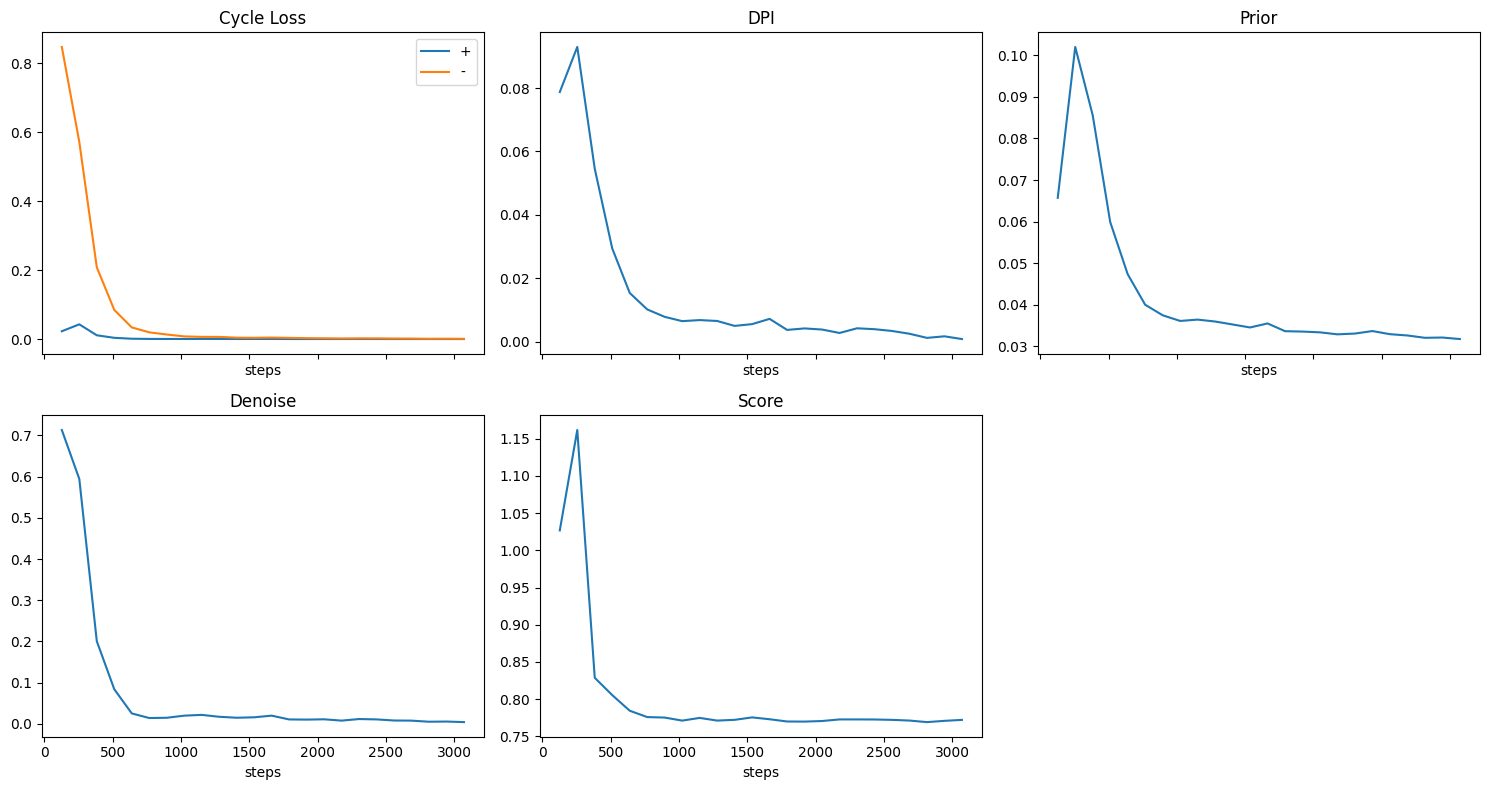

In [7]:
plot_training_curves(results["history"])

results["data_config"].dataset_config.visualize(
    points_by_class={
        "data": results["snapshot"]["x_true_hd"],
        "reconstruction": results["snapshot"]["x_recon_hd"],
        "model": results["snapshot"]["x_gen_hd"],
    },
).show(config={"scrollZoom": True})